# BERT Finetuning

This notebook demonstrates two approaches to finetuning BERT:
1. **Head-Only Finetuning**: Only train the classification layer (MLP head)
2. **Complete Finetuning**: Train all parameters including BERT layers

## Setup and Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertModel
from datasets import load_dataset
from tqdm import tqdm #used to print dynamic progress bar
from pprint import pprint #formats the complex python structures like dictionary, nested structures into readable form

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Load BERT Model and Tokenizer

In [3]:
# Load BERT model and tokenizer
print("Loading BERT model and tokenizer...")
bert_model = BertModel.from_pretrained('bert-base-uncased', output_hidden_states=True) #loading the pretrained BERT model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased') #Loading pretrained Wordpiece tokenizer

Loading BERT model and tokenizer...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## WordPiece Tokenization:

**WordPiece** is a **subword tokenization** method used by BERT.

Instead of representing every complete word as one token, WordPiece can
split a word into smaller, meaningful subwords.

$$
\boxed{\text{Word} \rightarrow \text{Subword Tokens}}
$$

---

## Example:

Consider the word:

$$
\texttt{unwanted}
$$

WordPiece can represent it as:

$$
\boxed{\texttt{unwanted}
\rightarrow
[\texttt{un},\texttt{##want},\texttt{##ed}]}
$$

Here, `##` indicates that the token is a continuation of the previous
subword.



**Sentence:**
"The researchers are studying unbelievable results."

**WordPiece tokens:**
[CLS] [the] [researchers] [are] [studying] **[un] [##believable]** [results] [.] [SEP]

**Sentence:**
"The researchers are studying unbelievable results."

**Regex tokens:**
[CLS] [the] [researchers] [are] [studying] **[unbelievable]** [results] [.] [SEP]

# **Advantages:** (vocabulary size reduction)

**WordPiece vocabulary:**
play

'##ing'

'##ed'

'##er'

'un'

'##happy'

'##ness'


**Word-level vocabulary:**

the

cat

play

playing

played

player

unwanted

unhappiness
...

→ potentially hundreds of thousands of words



$$
\boxed{
\text{WordPiece}
\rightarrow
\text{Smaller vocabulary}
+
\text{Handles rare/unseen words}
+
\text{Shorter sequences than character-level tokenization}
}
$$

In [4]:
# Move to device
bert_model = bert_model.to(device)
bert_model.eval()

#word Embedding(30522, 768, padding_idx=0) - 30522 words embedded as 768 dimension vector
#position Embedding(512, 768) - max sequence length is 512
#Sequence Embedding(2, 768) - only two sentences ID's is given
#LayerNorm((768,), eps=1e-12 - layer normalization across the dimension 768, the 'eps' is very small number used in denominator to prevent division by zero.
#(output): BertSelfOutput - this part do the linear projection of concatenated contexual embedding of all 12 attention head.

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

# **BERT ARCHITECTURE:**

```text
Input tokens
     │
     ├── Word Embedding
     ├── Position Embedding
     └── Token-Type Embedding
              │
              ▼
       Element-wise Addition
              │
              ▼
          LayerNorm
              │
              ▼
           Dropout
              │
              ▼
   ┌─────────────────────────┐
   │    BERT Encoder × 12    │
   │                         │
   │  Multi-Head Self-Attn   │
   │          │              │
   │       Dropout            │
   │          │              │
   │    Linear Projection    │
   │          │              │
   │     Residual + LayerNorm │
   │          │              │
   │         FFN              │
   │      Linear 768 → 3072   │
   │          │              │
   │        GELU              │
   │          │              │
   │      Linear 3072 → 768   │
   │          │              │
   │       Dropout            │
   │          │              │
   │     Residual + LayerNorm │
   └─────────────────────────┘
              │
              ▼
        Final BERT output

##BERT Token Embeddings

For BERT, each token is represented by a **768-dimensional embedding vector**.

For example, consider two tokens:

### Token 1: `the`

$$
\mathbf{E}_{\text{the}}
=
\begin{bmatrix}
0.21 & -0.43 & 0.17 & 0.82 & 0.35 & \cdots & -0.31
\end{bmatrix}
\in \mathbb{R}^{1\times768}
$$

### Token 2: `movie`

$$
\mathbf{E}_{\text{movie}}
=
\begin{bmatrix}
-0.56 & 0.14 & 0.73 & -0.29 & 0.91 & \cdots & 0.45
\end{bmatrix}
\in \mathbb{R}^{1\times768}
$$

Thus, two tokens produce two embedding vectors:

$$
\boxed{
\mathbf{E}_{\text{the}},\mathbf{E}_{\text{movie}}
\in\mathbb{R}^{1\times768}
}
$$

When placed together, they form a matrix:

$$
\mathbf{E}
=
\begin{bmatrix}
0.21 & -0.43 & 0.17 & 0.82 & 0.35 & \cdots & -0.31\\
-0.56 & 0.14 & 0.73 & -0.29 & 0.91 & \cdots & 0.45
\end{bmatrix}
\in\mathbb{R}^{2\times768}
$$

**Each row corresponds to one token, and each row contains 768 embedding values.**

## Token-Type Embeddings in BERT

BERT has **2 token-type embeddings**, each of dimension 768:

$$
\mathbf{T}_0 =
\begin{bmatrix}
0.12 & -0.34 & 0.56 & 0.21 & \cdots & 0.45
\end{bmatrix}
\in \mathbb{R}^{1\times768}
$$

$$
\mathbf{T}_1 =
\begin{bmatrix}
-0.27 & 0.41 & -0.63 & 0.18 & \cdots & -0.32
\end{bmatrix}
\in \mathbb{R}^{1\times768}
$$

Therefore:

$$
\boxed{
\mathbf{T}\in\mathbb{R}^{2\times768}
}
$$

where:

$$
\mathbf{T}
=
\begin{bmatrix}
\mathbf{T}_0\\
\mathbf{T}_1
\end{bmatrix}
=
\begin{bmatrix}
0.12 & -0.34 & 0.56 & 0.21 & \cdots & 0.45\\
-0.27 & 0.41 & -0.63 & 0.18 & \cdots & -0.32
\end{bmatrix}
$$

### What do Token Types 0 and 1 represent?

For a single sentence:

$$
\text{[CLS] The movie was excellent [SEP] I enjoyed it}
$$

all tokens belong to **segment/token type 0**:

```text
[CLS]  The  movie  was  excellent  [SEP] I enjoyed it
  0     0     0     0       0        0   1    1    1

# **GELU Vs RELU:**

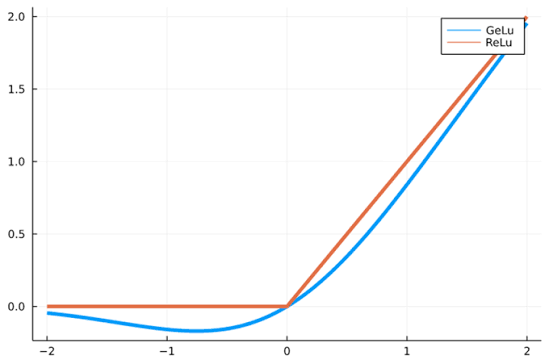

## Activation Functions: ReLU and GELU

### ReLU (Rectified Linear Unit)

$$
\boxed{
\text{ReLU}(x)=\max(0,x)
}
$$

or equivalently:

$$
\text{ReLU}(x)=
\begin{cases}
0, & x\leq0\\
x, & x>0
\end{cases}
$$

---

### GELU (Gaussian Error Linear Unit)

The commonly used approximation is:

$$
\boxed{
\text{GELU}(x)
\approx
\frac{1}{2}x
\left[
1+
\tanh\left(
\sqrt{\frac{2}{\pi}}
\left(x+0.044715x^3\right)
\right)
\right]
}
$$

Unlike ReLU, GELU provides a **smooth transformation** of the input rather than a hard cutoff at zero.

In [5]:
print(f"\nBERT Model Configuration:")
print(f"  - Number of layers: {bert_model.config.num_hidden_layers}")
print(f"  - Hidden size: {bert_model.config.hidden_size}") #hidden size represents the embedding dimension
print(f"  - Number of attention heads: {bert_model.config.num_attention_heads}")
print(f"  - Vocabulary size: {bert_model.config.vocab_size}")
print(f"  - Max position embeddings: {bert_model.config.max_position_embeddings}")


BERT Model Configuration:
  - Number of layers: 12
  - Hidden size: 768
  - Number of attention heads: 12
  - Vocabulary size: 30522
  - Max position embeddings: 512


# BERT for Sequence Classification

**Example:**

$$
\text{[CLS] The movie was excellent [SEP] I enjoyed it}
$$

### Token 0: `the`

$$
\mathbf{x}_{\text{0}}
=
\begin{bmatrix}
0.21 & -0.43 & 0.17 & 0.82 & 0.35 & \cdots & -0.31
\end{bmatrix}
\in \mathbb{R}^{1\times768}
$$

### Token 1: `movie`

$$
\mathbf{x}_{\text{1}}
=
\begin{bmatrix}
-0.56 & 0.14 & 0.73 & -0.29 & 0.91 & \cdots & 0.45
\end{bmatrix}
\in \mathbb{R}^{1\times768}
$$

..............

# Sequence Classification

## 1. Problem Setup

Given an input sequence:

$$
X = [x_0, x_1, \dots, x_{S-1}]
$$

where:
- $x_0 = [CLS]$
- $S$ is the sequence length

The task is to predict a label:

$$
y \in \{0, 1, \dots, C-1\}
$$

where:
- $C$ = number of classes  
  (e.g., $C = 2$ for positive/negative sentiment)

---

## 2. Transformer Encoder Output

The transformer produces contextual embeddings:

$$
H = [h_0, h_1, \dots, h_{S-1}]
$$

where:

$$
h_i \in \mathbb{R}^{d}
$$

For BERT-base:

$$
d = 768
$$

So:

$$
H \in \mathbb{R}^{S \times d}
$$

---

## 3. Sequence Representation (CLS Token)

We extract the representation of the special classification token:

$$
h_{\text{CLS}} = h_0
$$

$$
h_{\text{CLS}} \in \mathbb{R}^{d}
$$

Optionally (in BERT), apply the pooler layer:

$$
\tilde{h} = \tanh(W_p h_{\text{CLS}} + b_p)
$$

where:

$$
W_p \in \mathbb{R}^{d \times d}
$$

Now:

$$
\tilde{h} \in \mathbb{R}^{d}
$$

---

## 4. Classification Head

Apply a linear classifier:

$$
z = W_c \tilde{h} + b_c
$$

where:

$$
W_c \in \mathbb{R}^{C \times d}
$$

This produces logits:

$$
z \in \mathbb{R}^{C}
$$

---

## 5. Softmax Probabilities

Convert logits into probabilities:

$$
P(y = k \mid X) =
\frac{\exp(z_k)}
{\sum_{j=0}^{C-1} \exp(z_j)}
$$

for $k = 0, \dots, C-1$.

---

## 6. Cross-Entropy Loss

For one example:

$$
\mathcal{L} =
- \log P(y \mid X)
$$

More explicitly:

$$
\mathcal{L} =
- \sum_{k=0}^{C-1}
\mathbf{1}_{[y = k]} \log P(y = k \mid X)
$$



# **Final Classification head:**

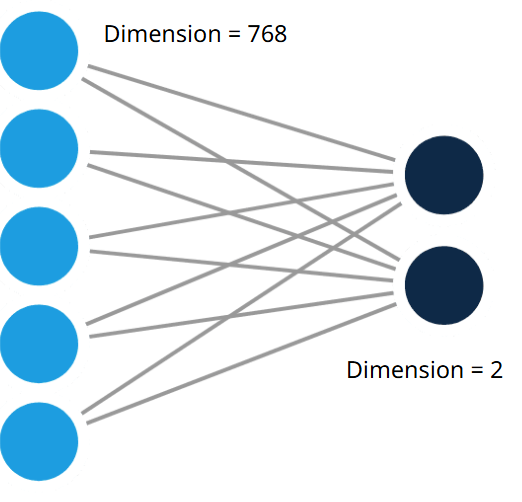

## Define Model



In [6]:
class BertForClassification(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.1): #represents the architecture, trainable parameters etc.. While making the object the parmeters of "init" will defined
        super().__init__()

        # Pretrained BERT encoder
        self.bert = BertModel.from_pretrained('bert-base-uncased')

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout_rate)

        # Classification head
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes) #it creates a linear layer whose input size = Contextual embedding after 12th encoder, Hidden state is just a nomenclature for the vector containing info.(as used in RNN) not the actual hidden layers.

    def forward(self, input_ids, attention_mask): #input_ids - are token ID's from BERT vocab, a sentence will provided something like this [101, 1045, 2293, 17953, 2361, 102, 0, 0, 0]
        # input_ids:      (B-batch size, L-sequence length)
        # attention_mask: (B, L) #attention mask is for ignore the padding used in the sentences

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ) #it is a container containing several different outputs

        # last_hidden_state: (B, L, H)
        hidden_states = outputs.last_hidden_state

        # cls_output: (B, H)
        cls_output = hidden_states[:, 0, :] #tensor slicing of [CLS] token

        # (B, H)
        cls_output = self.dropout(cls_output)

        # logits: (B, num_classes)
        logits = self.fc(cls_output)

        return logits

## Load and Prepare Dataset

In [7]:
# Load dataset
print("Loading IMDB dataset...")
ds = load_dataset("stanfordnlp/imdb")

#the dataset is stored 'Hugging face Datasetdict', it  is dictionary like container which has different splits of data like Train, test, validation with respective keywords.

train_size = 2000  # Use 5000 samples for training
test_size = 100   # Use 1000 samples for testing

print(f"Train dataset length = {len(ds['train'])}")
print(f"Test dataset length = {len(ds['test'])}")
# Shuffle first, then select samples
train_ds = ds['train'].shuffle(seed=42).select(range(train_size))
test_ds = ds['test'].shuffle(seed=42).select(range(test_size))




Loading IMDB dataset...
Train dataset length = 25000
Test dataset length = 25000


In [8]:
from collections import Counter

print("Train labels:")
print(Counter(train_ds["label"]))

print("\nTest labels:")
print(Counter(test_ds["label"]))

Train labels:
Counter({1: 1000, 0: 1000})

Test labels:
Counter({0: 53, 1: 47})


In [9]:
# Initialize tokenizer
print("Initializing BERT tokenizer...")
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def preprocess_function(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=128)

# Tokenize datasets
print("Tokenizing datasets...")
tokenized_train_ds = train_ds.map(preprocess_function, batched=True)
tokenized_test_ds = test_ds.map(preprocess_function, batched=True)

# Set format for PyTorch
tokenized_train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_test_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Initializing BERT tokenizer...
Tokenizing datasets...


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [10]:
# Create DataLoaders
batch_size = 16
train_loader = DataLoader(tokenized_train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(tokenized_test_ds, batch_size=batch_size)

## Training and Evaluation Functions

In [11]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in tqdm(dataloader, desc="Training"):
        input_ids = batch['input_ids'].to(device) # [B, L] #input_ids - already created and stored we are accessing it.
        attention_mask = batch['attention_mask'].to(device) #[B, L]
        labels = batch['label'].to(device) #[B,]

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

In [12]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total
    return avg_loss, accuracy

## Finetune Only the MLP Head (Classification Layer)

In [13]:
print("="*80)
print("FINETUNING ONLY THE MLP HEAD (Classification Layer)")
print("="*80)

# Initialize model for head-only finetuning
model_head_only = BertForClassification(num_classes=2).to(device)

# Freeze all BERT parameters
for param in model_head_only.bert.parameters(): # bert.parameters() - this will give us all the trainable parameter from the Bert layer excluding the classification layer
    param.requires_grad = False

# Verify which parameters are trainable
trainable_params = sum(p.numel() for p in model_head_only.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_head_only.parameters())


FINETUNING ONLY THE MLP HEAD (Classification Layer)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
print(f"\nTrainable parameters: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.2f}%)")


Trainable parameters: 1,538 / 109,483,778 (0.00%)


In [15]:
!pip uninstall -y torchvision torchaudio

In [16]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model_head_only.parameters()), lr=1e-3)
num_epochs = 3

# Train only the head
print(f"\nTraining for {num_epochs} epochs...")
for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_head_only, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model_head_only, test_loader, criterion, device)

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")


Training for 3 epochs...


Evaluating: 100%|██████████| 7/7 [00:00<00:00,  8.69it/s]



Epoch 1/3
Train Loss: 0.6057 | Train Acc: 66.55%
Test Loss: 0.5272 | Test Acc: 74.00%


Evaluating: 100%|██████████| 7/7 [00:00<00:00,  8.20it/s]



Epoch 2/3
Train Loss: 0.5256 | Train Acc: 74.05%
Test Loss: 0.4664 | Test Acc: 79.00%


Evaluating: 100%|██████████| 7/7 [00:00<00:00,  7.26it/s]


Epoch 3/3
Train Loss: 0.4931 | Train Acc: 76.45%
Test Loss: 0.5026 | Test Acc: 74.00%


In [17]:
# Final evaluation for head-only finetuning
print("\n" + "="*80)
print("FINAL RESULTS - HEAD ONLY FINETUNING")
print("="*80)
final_test_loss, final_test_acc = evaluate(model_head_only, test_loader, criterion, device)
print(f"Final Test Accuracy (Head Only): {final_test_acc:.2f}%")
print(f"Final Test Loss (Head Only): {final_test_loss:.4f}")


FINAL RESULTS - HEAD ONLY FINETUNING


Evaluating: 100%|██████████| 7/7 [00:00<00:00,  7.26it/s]

Final Test Accuracy (Head Only): 74.00%
Final Test Loss (Head Only): 0.5026


## Complete Finetuning (All Parameters)

In [18]:
print("\n" + "="*80)
print("PHASE 2: COMPLETE FINETUNING (All Parameters)")
print("="*80)

# Initialize new model for complete finetuning
model_full = BertForClassification(num_classes=2).to(device)

# All parameters are trainable by default
trainable_params = sum(p.numel() for p in model_full.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_full.parameters())


PHASE 2: COMPLETE FINETUNING (All Parameters)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [19]:
print(f"\nTrainable parameters: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.2f}%)")


Trainable parameters: 109,483,778 / 109,483,778 (100.00%)


In [20]:
optimizer_full = torch.optim.Adam(model_full.parameters(), lr=2e-5)
num_epochs_full = 3

# Train the full model
print(f"\nTraining for {num_epochs_full} epochs...")
for epoch in range(num_epochs_full):
    train_loss, train_acc = train_epoch(model_full, train_loader, optimizer_full, criterion, device)
    test_loss, test_acc = evaluate(model_full, test_loader, criterion, device)

    print(f"\nEpoch {epoch+1}/{num_epochs_full}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")


Training for 3 epochs...


Evaluating: 100%|██████████| 7/7 [00:00<00:00,  8.01it/s]



Epoch 1/3
Train Loss: 0.4653 | Train Acc: 77.70%
Test Loss: 0.3894 | Test Acc: 80.00%


Evaluating: 100%|██████████| 7/7 [00:00<00:00,  7.62it/s]



Epoch 2/3
Train Loss: 0.2291 | Train Acc: 90.90%
Test Loss: 0.3546 | Test Acc: 88.00%


Evaluating: 100%|██████████| 7/7 [00:00<00:00,  7.79it/s]


Epoch 3/3
Train Loss: 0.0940 | Train Acc: 96.85%
Test Loss: 0.3356 | Test Acc: 88.00%


In [21]:
# Final evaluation for complete finetuning
print("\n" + "="*80)
print("FINAL RESULTS - COMPLETE FINETUNING")
print("="*80)
final_test_loss_full, final_test_acc_full = evaluate(model_full, test_loader, criterion, device)
print(f"Final Test Accuracy (Complete Finetuning): {final_test_acc_full:.2f}%")
print(f"Final Test Loss (Complete Finetuning): {final_test_loss_full:.4f}")


FINAL RESULTS - COMPLETE FINETUNING


Evaluating: 100%|██████████| 7/7 [00:00<00:00,  7.75it/s]

Final Test Accuracy (Complete Finetuning): 88.00%
Final Test Loss (Complete Finetuning): 0.3356


In [22]:
# ============================================================
# Interactive BERT Classification
# ============================================================

import torch
import ipywidgets as widgets
from IPython.display import display, clear_output

# Put the model in evaluation mode
model_head_only.eval()

# Classification labels
class_names = {
    0: "Negative",
    1: "Positive"
}

# Text input box
sentence_box = widgets.Text(
    value="",
    placeholder="Enter a sentence...",
    description="Sentence:",
    layout=widgets.Layout(width="700px")
)

# Button
predict_button = widgets.Button(
    description="Classify",
    button_style="primary"
)

# Output area
output = widgets.Output()


def classify_sentence(sentence):
    # Tokenize the input sentence
    encoding = tokenizer(
        sentence,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    # Move tensors to GPU / CPU
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    # No gradient calculation during inference
    with torch.no_grad():
        logits = model_head_only(
            input_ids,
            attention_mask
        )

        # Convert logits → predicted class
        predicted_class = torch.argmax(logits, dim=1).item()

        # Convert logits → probabilities
        probabilities = torch.softmax(logits, dim=1)

    return predicted_class, probabilities


def on_predict(button):
    with output:
        clear_output()

        sentence = sentence_box.value.strip()

        if not sentence:
            print("Please enter a sentence.")
            return

        predicted_class, probabilities = classify_sentence(sentence)

        print(f"Sentence: {sentence}")
        print(f"\nPredicted class: {class_names[predicted_class]}")
        print(f"Class ID: {predicted_class}")

        print("\nProbabilities:")
        for class_id, probability in enumerate(probabilities[0]):
            print(
                f"  {class_names[class_id]}: "
                f"{probability.item() * 100:.2f}%"
            )


predict_button.on_click(on_predict)

display(sentence_box)
display(predict_button)
display(output)

Text(value='', description='Sentence:', layout=Layout(width='700px'), placeholder='Enter a sentence...')

Button(button_style='primary', description='Classify', style=ButtonStyle())

Output()